# 8.3. 오비탈과 에너지

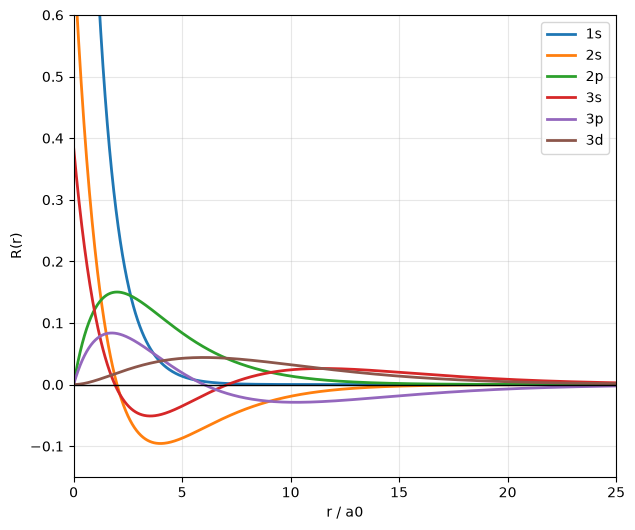

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import physical_constants

a0 = physical_constants["Bohr radius"][0]


def R(n, l, r):
    rho = r / a0
    radial = {
        (1, 0): 2 * np.exp(-rho),
        (2, 0): (1 / (2 * np.sqrt(2))) * (2 - rho) * np.exp(-rho / 2),
        (2, 1): (1 / np.sqrt(24)) * rho * np.exp(-rho / 2),
        (3, 0): (2 / (81 * np.sqrt(3))) * (27 - 18 * rho + 2 * rho**2) * np.exp(-rho / 3),
        (3, 1): (4 / (81 * np.sqrt(6))) * (6 * rho - rho**2) * np.exp(-rho / 3),
        (3, 2): (4 / (81 * np.sqrt(30))) * rho**2 * np.exp(-rho / 3),
    }

    return a0 ** (-3 / 2) * radial[(n, l)]


r = np.linspace(1e-6 * a0, 25 * a0, 1000)
states = [(1, 0, "1s"), (2, 0, "2s"), (2, 1, "2p"), (3, 0, "3s"), (3, 1, "3p"), (3, 2, "3d")]

fig, ax = plt.subplots(figsize=(7, 6))
for n, l, name in states:
    ax.plot(r / a0, R(n, l, r) * a0 ** (3 / 2), lw=2, label=name)
ax.axhline(0, color="black", lw=1)
ax.set_xlim(0, 25)
ax.set_ylim(-0.15, 0.6)
ax.set_xlabel("r / a0", fontsize=10)
ax.set_ylabel("R(r)", fontsize=10)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.show()

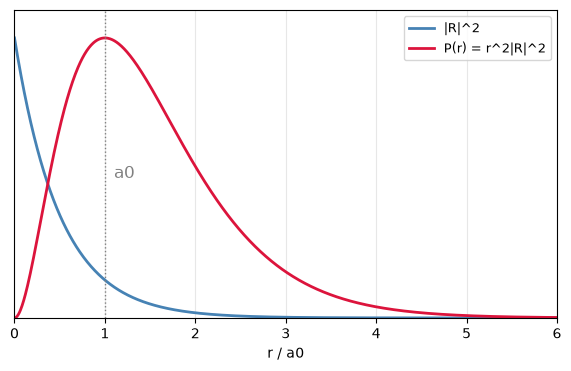

In [2]:
r = np.linspace(1e-6 * a0, 6 * a0, 1000)
R1 = R(1, 0, r)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(r / a0, R1**2 / (R1**2).max(), lw=2, color="steelblue", label="|R|^2")
P1 = r**2 * R1**2
ax.plot(r / a0, P1 / P1.max(), lw=2, color="crimson", label="P(r) = r^2|R|^2")
ax.axvline(1, color="gray", ls=":", lw=1)
ax.text(1.1, 0.5, "a0", fontsize=12, color="gray")
ax.set_xlim(0, 6)
ax.set_ylim(0, 1.1)
ax.set_xlabel("r / a0")
ax.set_yticks([])
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.show()

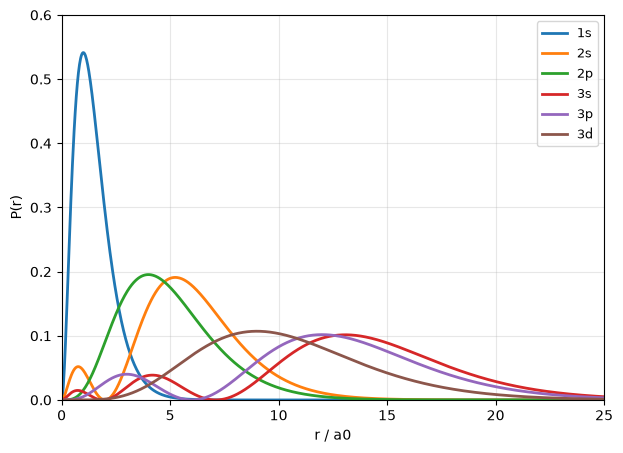

 (n, l)      최대 위치        <r>
 (1, 0)      1.00 a0     1.50 a0
 (2, 0)      5.24 a0     6.00 a0
 (2, 1)      4.00 a0     5.00 a0
 (3, 0)     13.07 a0    13.50 a0
 (3, 1)     12.00 a0    12.50 a0
 (3, 2)      9.00 a0    10.50 a0


In [3]:
r = np.linspace(1e-6 * a0, 25 * a0, 1000)

fig, ax = plt.subplots(figsize=(7, 5))
for n, l, name in states:
    ax.plot(r / a0, r**2 * R(n, l, r) ** 2 * a0, lw=2, label=name)
ax.set_xlim(0, 25)
ax.set_ylim(0, 0.6)
ax.set_xlabel("r / a0")
ax.set_ylabel("P(r)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.show()

rw = np.linspace(1e-8 * a0, 45 * a0, 50000)

print(f"{'(n, l)':>7} {'최대 위치':>10} {'<r>':>10}")
for n, l, _ in states:
    P = rw**2 * R(n, l, rw) ** 2
    r_max = rw[np.argmax(P)] / a0
    r_mean = np.trapezoid(P * rw, rw) / a0
    print(f"{str((n, l)):>7} {r_max:9.2f} a0 {r_mean:8.2f} a0")

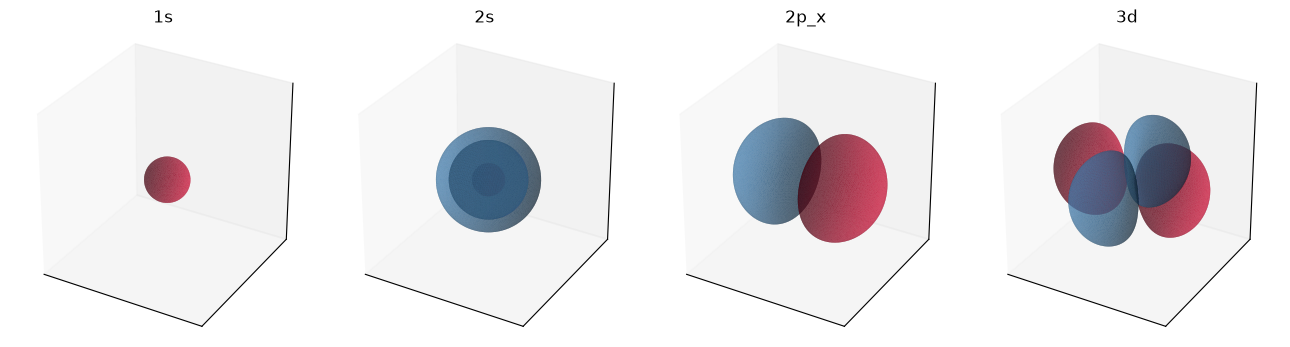

In [4]:
from scipy.special import sph_harm_y
from skimage import measure


def real_Y(l, m, th, ph):
    if m == 0:
        return sph_harm_y(l, 0, th, ph).real
    elif m > 0:
        return np.sqrt(2) * (-1) ** m * sph_harm_y(l, m, th, ph).real
    else:
        return np.sqrt(2) * (-1) ** m * sph_harm_y(l, -m, th, ph).imag


def orbital_grid(n, l, m, l_box, N=100):
    g = np.linspace(-l_box, l_box, N)
    X, Y, Z = np.meshgrid(g, g, g, indexing="ij")
    r = np.sqrt(X**2 + Y**2 + Z**2) + 1e-12 * a0
    th = np.arccos(np.clip(Z / r, -1, 1))
    ph = np.arctan2(Y, X)
    return g, R(n, l, r) * real_Y(l, m, th, ph)


def draw(ax, psi, g, frac=0.25, title=""):
    level = np.abs(psi).max() * frac
    d = g[1] - g[0]
    for lv, col in [(level, "crimson"), (-level, "steelblue")]:
        if not psi.min() < lv < psi.max():
            continue
        v, f, _, _ = measure.marching_cubes(psi, lv, spacing=(d,) * 3)
        v = v + g[0]
        ax.plot_trisurf(v[:, 0] / a0, v[:, 1] / a0, f, v[:, 2] / a0, color=col, alpha=0.6, lw=0)
    L = g.max() / a0
    ax.set_xlim(-L, L)
    ax.set_ylim(-L, L)
    ax.set_zlim(-L, L)
    ax.set_box_aspect((1, 1, 1))
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.set_title(title, fontsize=12)


fig = plt.figure(figsize=(13, 4))
for i, (n, l, m, l_box, name) in enumerate(
    [(1, 0, 0, 8 * a0, "1s"), (2, 0, 0, 8 * a0, "2s"), (2, 1, 1, 10 * a0, "2p_x"), (3, 2, 2, 20 * a0, "3d")], 1
):
    ax = fig.add_subplot(1, 4, i, projection="3d")
    g, psi = orbital_grid(n, l, m, l_box)
    draw(ax, psi, g, frac=0.15, title=name)

plt.tight_layout()
plt.show()